In [21]:
from astropy.coordinates import ICRS
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time, TimeDelta
from astropy.coordinates import EarthLocation
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import ICRS
from src.load_params import *
from src.scan_fcts import *
from gen_timestreams import *
from scipy.interpolate import interp1d
from scipy.ndimage import label
from scipy.interpolate import PchipInterpolator
#Load the sky simulation from which to generate the TODs from
P = load_params('PAR_files/params_strategy.par')
ra = 0; dec = - 27; lat = P['latitude']

simu_sky_path = P['path']+P['file'] #os.getcwd()
hdr  = fits.getheader(simu_sky_path)
pix_size = ((hdr['CDELT1']*u.Unit(hdr['CUNIT1']))**2).to(u.sr).value
hdr['CRVAL1'] = ra 
hdr['CRVAL2'] = dec
hdr['CRPIX1'] = hdr['NAXIS1']//2
hdr['CRPIX2'] = hdr['NAXIS2']//2
wcs = WCS(hdr, naxis=2) 
#Create the list of frequency channels of the simulated cube. 
freqs =( np.arange(hdr['CRVAL3'], hdr['CRVAL3']+hdr['NAXIS3']*hdr['CDELT3'], hdr['CDELT3'])*u.Unit(hdr['CUNIT3']) ).to(u.GHz)
#Create the binning of the map in pixel coordinates. 
xbins = np.arange(-0.5, hdr['NAXIS1']+0.5, 1)
ybins = np.arange(-0.5, hdr['NAXIS2']+0.5, 1)
#load the angular spectral cube. 
cube = fits.getdata(simu_sky_path)
#Remove the mean in each map, to wich we are not sensitive. 
cubemean = np.mean(cube, axis=(1,2)) 
cube -= cubemean[:, None, None]
cube *= 1e6*pix_size #conversion MJy/sr to Jy/beam

In [26]:
T_duration = 15/60

f1 = 244.63
f2 = 366.7
f3 = 488.3
final_frequency = 110 #Hz

first_frame = 15
num_frames = 60*3


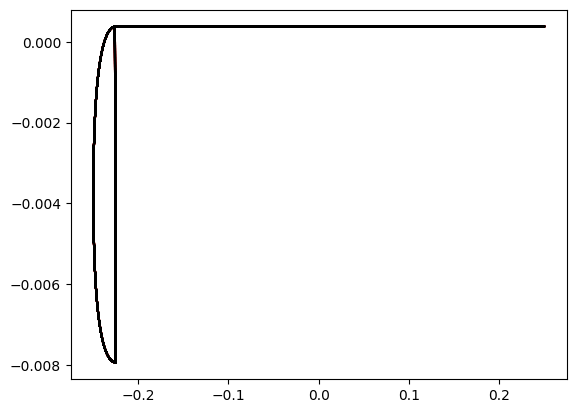

In [27]:
#----
#Actual coordinates
dtcoords = (1/f2/3600)*np.pi/3.14 #Make the timestep non rational to avoid some stripes in the hitmap. 
LSTcoords = np.arange(-T_duration/2, T_duration/2, dtcoords)  # in hours

spf_coord = int(1/np.round(dtcoords*3600,3)) #sample per frame defined here as the acquisition rate in Hz. 
Tcoords = np.arange(0, T_duration, dtcoords) * 3600  # seconds
az_coords, alt_coords, flag = genLocalPath_cst_el_scan(az_size=P['az_size'], alt_size=P['alt_size'], alt_step=P['alt_step'], acc=P['acc'], scan_v=P['scan_v'], dt=np.round(dtcoords*3600,3))
scan_path_coords, scan_flag_coords = genScanPath(Tcoords, alt_coords, az_coords, flag)

plt.plot(scan_path_coords[:,0],scan_path_coords[:,1],'r')
plt.plot(scan_path_coords[:,0],scan_path_coords[:,1],'k')
#---------------------------------------------------------------------------
# Get sorted indices of time_array
#sorted_indices = np.argsort(Tcoords)
# Apply the sorting
#Tcoords = Tcoords[sorted_indices]
#coords = scan_path_coords[sorted_indices,:]
#---------------------------------------------------------------------------
coords =   scan_path_coords[first_frame*spf_coord:(first_frame+num_frames)*spf_coord,:]
T_coords = Tcoords[first_frame*spf_coord:(first_frame+num_frames)*spf_coord]
scan_flag_coords = scan_flag_coords[first_frame*spf_coord:(first_frame+num_frames)*spf_coord]
#----

/tmp/ipykernel_97348/71023200.py:33: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc3 = axs[1].scatter(scan_path_sky[:,0],scan_path_sky[:,1],c='white',  cmap='viridis', s=1)


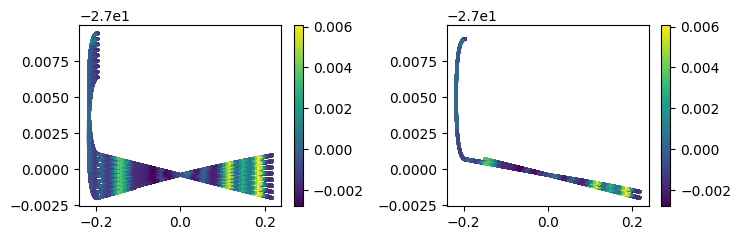

In [28]:
#----
#Actual data
dt = (1/f3/3600)*np.pi/3.14 #Make the timestep non rational to avoid some stripes in the hitmap. 
spf_data = int(1/np.round(dt*3600,3)) #sample per frame defined here as the acquisition rate in Hz. 
LST = np.arange(-T_duration/2, T_duration/2, dt)  # in hours
Tdata = np.arange(0, T_duration, dt) * 3600  # seconds

az, alt, flag = genLocalPath_cst_el_scan(az_size=P['az_size'], alt_size=P['alt_size'], alt_step=P['alt_step'], acc=P['acc'], scan_v=P['scan_v'], dt=np.round(dt*3600,3))
scan_path, scan_flag = genScanPath(Tdata, alt, az, flag)

scan_path_sky, azel = genPointingPath(Tdata, scan_path, LST, lat, dec, ra, azel=True) 

Map = cube[0,:,:]
hist, norm, samples, positions_x, positions_y = gen_tod(wcs, Map, hdr, ybins, xbins, (scan_path_sky,))
#---------------------------------------------------------------------------
# Get sorted indices of time_array
#sorted_indices = np.argsort(Tdata)
# Apply the sorting
#Tdata = Tdata[sorted_indices]
#data = (samples[0])[sorted_indices]

data = (samples[0])[first_frame*spf_data:(first_frame+num_frames)*spf_data]
T_data       = Tdata[first_frame*spf_data:(first_frame+num_frames)*spf_data]
scan__path_sky = scan_path_sky[first_frame*spf_data:(first_frame+num_frames)*spf_data,:]
scan_flag = scan_flag[first_frame*spf_data:(first_frame+num_frames)*spf_data]
#---------------------------------------------------------------------------

fig, axs = plt.subplots(1,2, figsize=(7.5,2.5))

sc3 = axs[0].scatter(scan_path_sky[:,0],scan_path_sky[:,1],c=samples[0],  cmap='viridis', s=2)      
plt.colorbar(sc3, ax=axs[0], ) 

sc3 = axs[1].scatter(scan_path_sky[:,0],scan_path_sky[:,1],c='white',  cmap='viridis', s=1)      

sc3 = axs[1].scatter(scan__path_sky[:,0],scan__path_sky[:,1],c=data,  cmap='viridis', s=2)      
plt.colorbar(sc3, ax=axs[1], ) 

fig.tight_layout()     


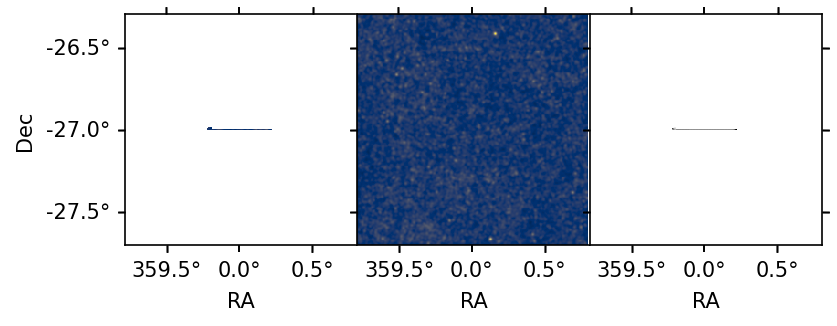

In [29]:
fig, axs = plt.subplots(1,3, figsize=(6,3), dpi = 150,subplot_kw={'projection': wcs}, sharex=True, sharey=True )
imgdec = axs[0].imshow(hist, interpolation='nearest', origin='lower', vmin=Map.min(), vmax=Map.max(), cmap='cividis' )
img = axs[1].imshow(Map, interpolation='nearest', origin='lower', vmin=Map.min(), vmax=Map.max(), cmap='cividis' )
count = axs[2].imshow(norm, interpolation='nearest', origin='lower', cmap='binary' )
for ax in (axs[0], axs[1], axs[2]):
    lon = ax.coords[0]
    LAT = ax.coords[1]
    LAT.set_major_formatter('d.d')
    lon.set_major_formatter('d.d')
    lon.set_axislabel('RA')
    LAT.set_axislabel('Dec')
    if(ax is not axs[0]): ax.tick_params(axis='y', labelleft=False)
plt.subplots_adjust(wspace=0, hspace=0)
#----

In [30]:
def resampling(X, spf_start, spf_end):
    ratio = spf_start / spf_end
    interper = PchipInterpolator(np.arange(0, len(X)), X)
    x = interper(np.arange(0, len(X), ratio)) # t -= t[0]
    return x

/tmp/ipykernel_97348/188992054.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0].scatter(scan_path_coords[:,0],scan_path_coords[:,1],c='w',  cmap='viridis', s=1)
/tmp/ipykernel_97348/188992054.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[1].scatter(scan_path_coords[:,0],scan_path_coords[:,1],c='w',  cmap='viridis', s=1)
/tmp/ipykernel_97348/188992054.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[2].scatter(scan_path_coords[:,0],scan_path_coords[:,1],c='w',  cmap='viridis', s=1)


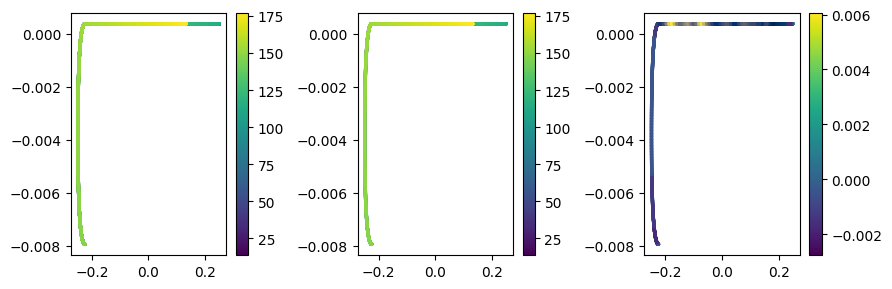

In [31]:
az_resampled =      resampling(coords[:,0], spf_coord,final_frequency)
el_resampled =      resampling(coords[:,1], spf_coord,final_frequency)
Tcoords_resampled = resampling(T_coords,    spf_coord,final_frequency)
scan_flag_coords_resampled = resampling(scan_flag_coords, spf_coord,final_frequency)

data_resampled = resampling(data,     spf_data,final_frequency)
T_data_resampled = resampling(T_data, spf_data,final_frequency)

fig, axs = plt.subplots(1,3, figsize=(9,3))

axs[0].scatter(scan_path_coords[:,0],scan_path_coords[:,1],c='w',  cmap='viridis', s=1)      
sc3 = axs[0].scatter(coords[:,0],coords[:,1],c=T_coords,  cmap='viridis', s=2)      
plt.colorbar(sc3, ax=axs[0], ) 

axs[1].scatter(scan_path_coords[:,0],scan_path_coords[:,1],c='w',  cmap='viridis', s=1)  
sc3 = axs[1].scatter(az_resampled,el_resampled,c=Tcoords_resampled, cmap='viridis', s=2)      
plt.colorbar(sc3, ax=axs[1], ) 

axs[2].scatter(scan_path_coords[:,0],scan_path_coords[:,1],c='w',  cmap='viridis', s=1)  
sc3 = axs[2].scatter(az_resampled,el_resampled,c=data_resampled, cmap='viridis', s=2)      
plt.colorbar(sc3, ax=axs[2], ) 
sc3 = axs[2].scatter(az_resampled[scan_flag_coords_resampled==1],el_resampled[scan_flag_coords_resampled==1],c=data_resampled[scan_flag_coords_resampled==1], cmap='cividis', s=2)      

fig.tight_layout()  

ValueError: x and y must have same first dimension, but have shapes (329862,) and (59939,)

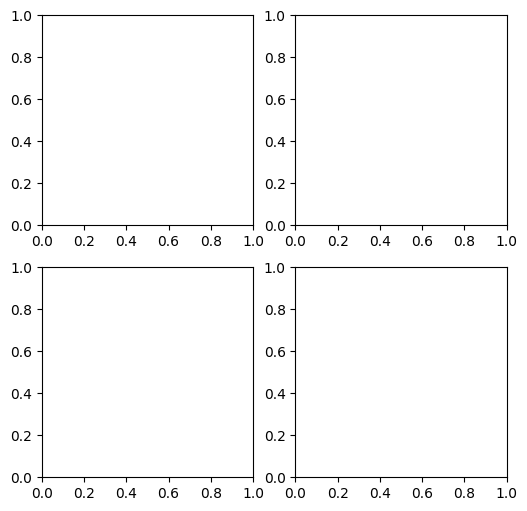

In [32]:
# Compute acceleration using finite difference
time_mid = (Tcoords[:-1] + Tcoords[1:]) / 2
dt = dtcoords*3600

# 2. Compute velocities
dpos = np.diff(coords, axis=0)         # shape (N-1, 2)
velocity = dpos / dt          # shape (N-1, 2)
velocity_magnitude = np.linalg.norm(velocity, axis=1)

dvel = np.diff(velocity, axis=0)       # shape (N-2, 2)
acceleration = dvel / dt # shape (N-2, 2)

# 4. Compute scalar acceleration (optional)
acc_magnitude = np.linalg.norm(acceleration, axis=1)

# Optional: compute time values associated with each acceleration sample
t_acc = (Tcoords[:-2] + Tcoords[2:]) / 2  # shape (N-2,)

fig, axs = plt.subplots(2,2, figsize = (6,6))
axa,axc,axb,axd = axs[0,0], axs[0,1], axs[1,0], axs[1,1]

axa.plot(time_mid, velocity_magnitude, '-k')
axc.plot(coords[1:,0], coords[1:,1], '.k')
B = scan_path_coords[scan_flag_coords==1]
axc.plot(B[:,0], B[:,1],'.g')

axb.plot(t_acc, acc_magnitude, '-k')

a_thresh = 0.001 # units depend on your data (e.g., deg/s²)

# Boolean mask: True = acceleration, False = constant speed
is_accelerating = (np.abs(acc_magnitude) > a_thresh) | (np.abs(acc_magnitude) > a_thresh)
const_speed_mask = ~is_accelerating

axb.plot(t_acc[is_accelerating==1],acc_magnitude[is_accelerating==1], 'ob')
axb.plot(t_acc[const_speed_mask==1],acc_magnitude[const_speed_mask==1], '*g')
#
axd.plot(coords[2:,0][is_accelerating], coords[2:,1][is_accelerating],'*b')
axd.plot(coords[2:,0][const_speed_mask], coords[2:,1][const_speed_mask],'*g')